# Telecom Customer Churn: Exploratory Data Analysis

Explore data quality, customer characteristics, and churn patterns in the IBM Telco dataset. This analysis is observational: differences in churn rates do not establish causation.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv").is_file()
)
file_path = project_root / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")
churn_palette = {"No": "#4C78A8", "Yes": "#E45756"}




In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())
df.info()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data quality assessment

The dataset contains 7,043 rows and 21 columns. The initial inspection identifies two issues that should be resolved before analysis:

- `SeniorCitizen` is stored as binary integers (`0` and `1`) while comparable indicator fields use `Yes` and `No`. Converting it to consistent labels improves readability.
- `TotalCharges` is stored as text rather than a numeric field, which prevents reliable numerical summaries and visualization.

The `customerID` field is an identifier rather than a feature that can be used by the model, so it should be removed after making sure there are no duplicates.

In [3]:
print("Duplicated rows:", df.duplicated().sum())
print("Duplicated customer IDs:", df["customerID"].duplicated().sum())
print("Unique customer IDs:", df["customerID"].nunique())

Duplicated rows: 0
Duplicated customer IDs: 0
Unique customer IDs: 7043


The dataset contains no duplicated rows or customer IDs. All 7,043 customer IDs are unique, so each row represents a distinct customer record.

In [4]:
# Drop customerID column as it is useless for analysis
df = df.drop("customerID", axis=1)

df = df.assign(
        SeniorCitizen=df["SeniorCitizen"].map({
            1: "Yes",
            0: "No"
        })
    )

text_columns = df.select_dtypes(include="str").columns

# Remove leading and trailing spaces
df[text_columns] = df[text_columns].apply(
    lambda column: column.str.strip()
)

# Convert TotalCharges column from str to correct number format
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

# Check for missing values in the new converted column
missing_values = df["TotalCharges"].isna()
display(df[missing_values])
print(f"Missing rows: {missing_values.sum()}")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Missing rows: 11


Converting `TotalCharges` to a numeric type reveals 11 missing values that were originally stored as blank strings. Every affected record has `tenure = 0` and `Churn = No`, which is consistent with a newly activated customer who has not yet accumulated any charges.

For these specific records, imputing `TotalCharges` as `0` is a logical solution to fill the gaps.

In [5]:
# Make sure to only select the missing values where tenure = 0
# and Churn = No, which represents a new customer.
new_customer_missing_charge = (
    missing_values
    & df["tenure"].eq(0)
    & df["Churn"].eq("No")
)

# Change the new customer TotalCharges to 0
df.loc[
    new_customer_missing_charge,
    "TotalCharges"
] = 0

# Verify
display(df.loc[
    missing_values,
    ["tenure", "TotalCharges", "Churn"]
])

,tenure,TotalCharges,Churn
488,0,0.0,No
753,0,0.0,No
936,0,0.0,No
1082,0,0.0,No
1340,0,0.0,No
3331,0,0.0,No
3826,0,0.0,No
4380,0,0.0,No
5218,0,0.0,No
6670,0,0.0,No


The 11 newly activated accounts now have `TotalCharges = 0`. The validation below confirms that the correction was limited to records with a missing total, zero tenure, and no recorded churn.

## Exploratory analysis

### 1. Overall churn rate

What proportion of customers churned, and is the target sufficiently balanced for standard model evaluation?

,Churn,Percentage
0,No,73.46
1,Yes,26.54


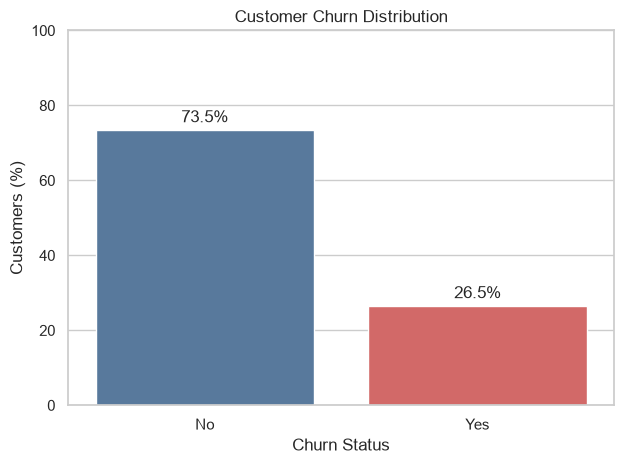

In [6]:
# Calculate the percentage of 'Yes' and 'No' data
# and place them in a dataframe layout for creating the chart
churn_distribution = (
    df["Churn"]
    .value_counts(normalize=True) 
    .mul(100)
    .reindex(["No", "Yes"])
    .rename_axis("Churn")
    .reset_index(name="Percentage")
)
display(churn_distribution.round(2))

# Pass the chart data to create using seaborn
# and configrue the chart axis using ax object
ax = sns.barplot(
    data=churn_distribution,
    x="Churn",
    y="Percentage",
    hue="Churn",
    palette=churn_palette,
    legend=False
)

# Configure each bar label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
)

# Set axis labels
ax.set(
    title="Customer Churn Distribution",
    xlabel="Churn Status",
    ylabel="Customers (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()


#### Key insight

Of the 7,043 customers, 26.54% churned and 73.46% remained. Churners are therefore the minority class, at roughly one churned customer for every 2.8 retained customers.

This moderate class imbalance means accuracy alone could be misleading: a model may appear successful while failing to identify many churners. F2-score is used as the model-selection target because it combines precision and recall while giving recall twice as much weight. Precision, recall, F1-score, and the confusion matrix are also reported to explain each model's errors.

### 2. Missing-value validation

After cleaning, check every column for both standard missing values and empty strings.

In [7]:
# Detect regular missing values 
missing_values = df.isna().sum()

# Detect empty strings
text_columns = df.select_dtypes(include="str").columns

blank_values = df[text_columns].apply(
    lambda column: column.str.strip().eq("").sum()
)

missing_summary = pd.DataFrame({
    "Missing values": missing_values,
    "Blank strings": blank_values
}).fillna(0).astype(int)

display(missing_summary[
    missing_summary.sum(axis=1) > 0
])


,Missing values,Blank strings


No missing values or blank strings remain after cleaning. The dataset is complete and ready for exploratory analysis.

### 3. Tenure and churn

Compare customer tenure for churned and retained customers to determine whether churn is concentrated at a particular stage of the customer lifecycle.

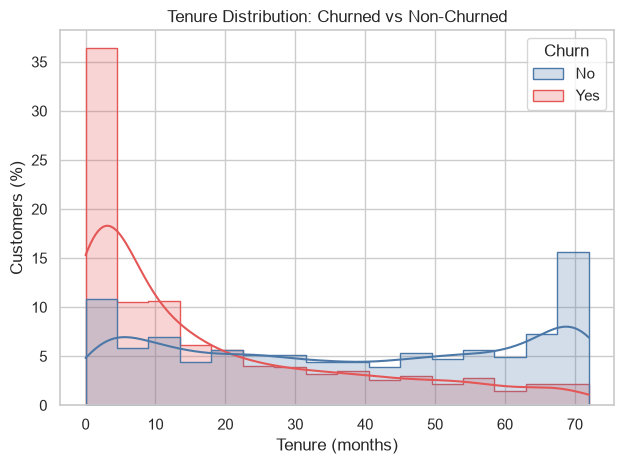

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [8]:
ax = sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    palette=churn_palette,
    kde=True,
    element="step",
    stat="percent",
    common_norm=False
)

ax.set(
    title="Tenure Distribution: Churned vs Non-Churned",
    xlabel="Tenure (months)",
    ylabel="Customers (%)"
)

plt.tight_layout()
plt.show()

tenure_by_churn = df.groupby("Churn")["tenure"].describe()
tenure_by_churn.round(2)

#### Key insight

Customers who churned generally had much shorter tenures. Their average tenure was 17.98 months and their median was 10 months, compared with 37.57 months and 38 months for customers who did not churn. 

The separation is also visible across the distributions: 75% of churned customers had been subscribed for 29 months or less, whereas the corresponding threshold for retained customers was 61 months. Churn is therefore concentrated earlier in the customer lifecycle, making onboarding and early-tenure engagement important areas for retention efforts.

### 4. Contract type and churn

Compare churn rates across month-to-month, one-year, and two-year contracts.

,Contract,Churn Rate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


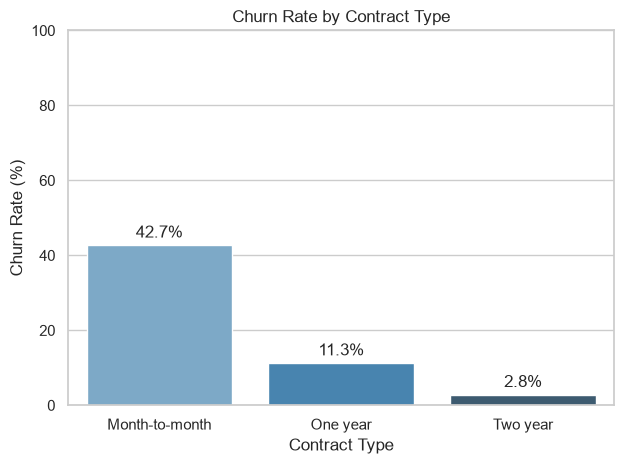

In [9]:
contract_churn_rates = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["Month-to-month", "One year", "Two year"])
    .rename_axis("Contract")
    .reset_index(name="Churn Rate")
)
display(contract_churn_rates.round(2))

ax = sns.barplot(
    data=contract_churn_rates,
    x="Contract",
    y="Churn Rate",
    hue="Contract",
    palette="Blues_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Contract Type",
    xlabel="Contract Type",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. That is a difference of 31.44 percentage points versus one-year contracts and 39.88 points versus two-year contracts.

The strong gradient suggests that longer commitments are associated with greater retention. However, contract type may also reflect customer tenure, pricing, or self-selection, so the relationship should not be interpreted as causal without further analysis.

### 5. Internet service and churn

How does churn vary among DSL, fiber-optic, and non-internet customers?

,Internet Service,Churn Rates
0,DSL,18.96
1,Fiber optic,41.89
2,No,7.40


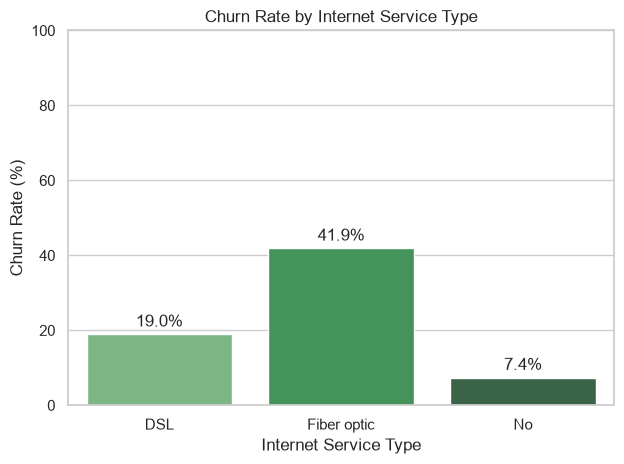

In [10]:
internet_churn_rates = (
    df.groupby("InternetService")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["DSL", "Fiber optic", "No"])
    .rename_axis("Internet Service")
    .reset_index(name="Churn Rates")
)
display(internet_churn_rates.round(2))

ax = sns.barplot(
    data=internet_churn_rates,
    x="Internet Service",
    y="Churn Rates",
    hue="Internet Service",
    palette="Greens_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Internet Service Type",
    xlabel="Internet Service Type",
    ylabel="Churn Rate (%)",
    ylim=(0,100)
)

plt.tight_layout()
plt.show()



#### Key insight

Internet service type has a noticeable relationship with churn. Fiber optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. 

The fiber-optic churn rate is 22.93 percentage points higher than DSL and 34.49 points higher than no internet service. This makes fiber-optic customers a high-priority segment for deeper investigation into price, service quality, contract mix, and support experience. The result is an association and does not establish that fiber service itself causes churn.

### 6. Payment method and churn

Compare churn rates across payment methods and identify the highest-risk group.

,Payment Method,Churn Rates
0,Bank transfer (automatic),16.71
1,Credit card (automatic),15.24
2,Electronic check,45.29
3,Mailed check,19.11


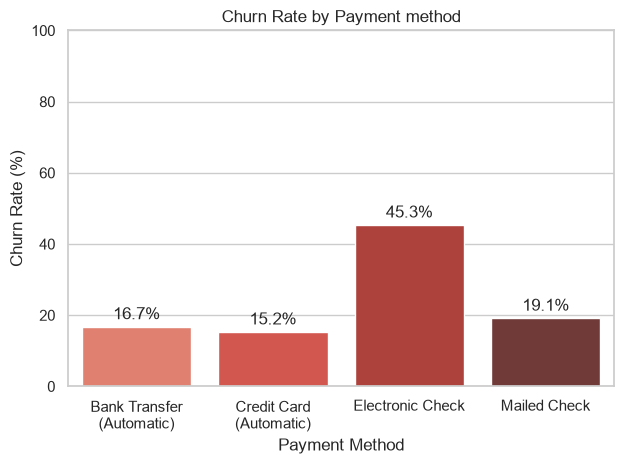

In [11]:
payment_churn_rates = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["Bank transfer (automatic)", "Credit card (automatic)", "Electronic check", "Mailed check"])
    .rename_axis("Payment Method")
    .reset_index(name="Churn Rates")
)
display(payment_churn_rates.round(2))

ax = sns.barplot(
    data=payment_churn_rates,
    x="Payment Method",
    y="Churn Rates",
    hue="Payment Method",
    palette="Reds_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Payment method",
    xlabel="Payment Method",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

ax.set_xticks(
    ax.get_xticks(),
    ["Bank Transfer\n(Automatic)", "Credit Card\n(Automatic)",
    "Electronic Check", "Mailed Check"]
)

plt.tight_layout()
plt.show()

#### Key insight

Electronic-check customers have the highest churn rate at 45.29%. The rates for mailed check (19.11%), automatic bank transfer (16.71%), and automatic credit card (15.24%) are substantially lower.

Electronic check is therefore associated with a 26.18–30.05 percentage-point increase relative to the other methods. This group may overlap with month-to-month or paperless-billing customers, so multivariate analysis is needed before attributing the difference to payment method alone.

### 7. Monthly charges and churn

Compare average monthly charges for churned and retained customers.

,Churn,Average Monthly Charge
0,No,61.27
1,Yes,74.44


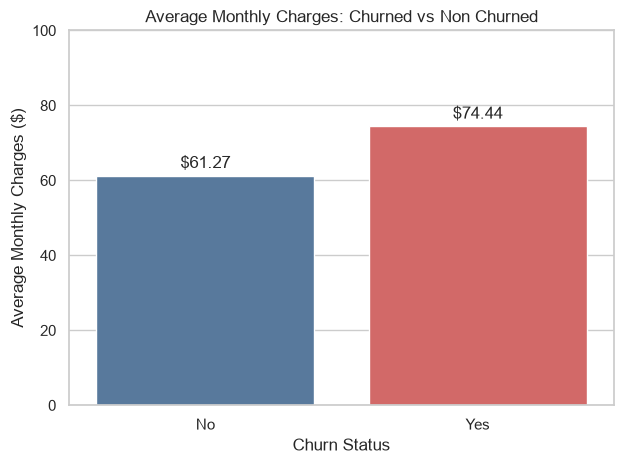

In [12]:
monthly_charges_av_by_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
    .rename_axis("Churn")
    .reset_index(name="Average Monthly Charge")
)
display(monthly_charges_av_by_churn.round(2))

ax= sns.barplot(
    data=monthly_charges_av_by_churn,
    x="Churn",
    y="Average Monthly Charge",
    hue="Churn",
    palette=churn_palette,
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="$%.2f",
        padding=3
    )

ax.set(
    title="Average Monthly Charges: Churned vs Non Churned",
    xlabel="Churn Status",
    ylabel="Average Monthly Charges ($)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()


#### Key insight

Churned customers paid an average of $74.44 per month, compared with $61.27 for retained customers—a difference of approximately $13.18, or 21.5% relative to the retained-customer average.

Higher monthly charges are associated with churn, but the comparison does not control for service bundle, internet type, or contract. Those factors may explain part of the observed difference.

### 8. Online security, technical support, and churn

Do internet customers without online security or technical support churn more frequently than customers who subscribe to these services?

,Service,Status,Churn Rate
0,Online Security,Without,41.77
1,Online Security,No Internet Service,7.40
2,Online Security,With,14.61
3,Tech Support,Without,41.64
4,Tech Support,No Internet Service,7.40
5,Tech Support,With,15.17


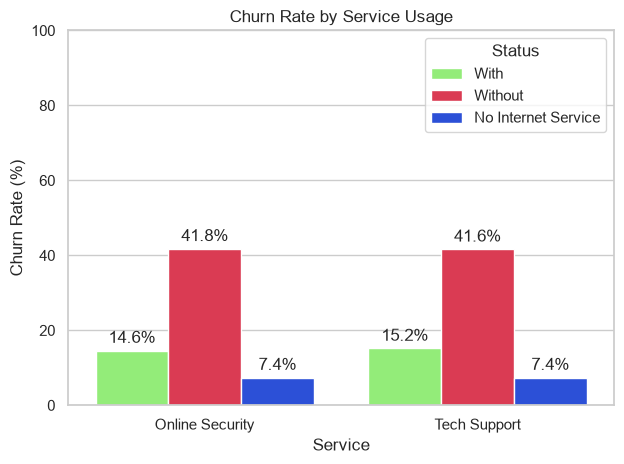

In [13]:
services = {"OnlineSecurity": "Online Security", "TechSupport": "Tech Support"}

services_churn = (
    pd.concat(
        {
            label: df.groupby(col)["Churn"]
                        .value_counts(normalize=True)
                        .xs("Yes", level="Churn")
                        .mul(100)
                        .rename({"Yes": "With", "No": "Without", "No internet service": "No Internet Service"})
            for col, label in services.items()
        },
        names=["Service", "Status"]
    )
    .rename("Churn Rate")
    .reset_index()
)
display(services_churn.round(2))

ax = sns.barplot(
    data=services_churn,
    x="Service",
    y="Churn Rate",
    hue="Status",
    hue_order=["With", "Without", "No Internet Service"],
    palette={"With": "#8f6", "Without": "#f52040", "No Internet Service": "#1040f3"}
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Service Usage",
    xlabel="Service",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Among internet customers, those without online security churned at 41.77%, compared with 14.61% for subscribers—a gap of 27.16 percentage points. Similarly, customers without technical support churned at 41.64%, compared with 15.17% for subscribers—a gap of 26.47 points.

Both services are strongly associated with retention. They may also act as proxies for bundle depth, engagement, or customer needs, so controlled modeling is required before treating service enrollment as the direct cause.

### 9. Churn by tenure segment

Group customers by tenure to identify the lifecycle stage with the greatest retention risk.

,TenureGroup,Customers,Churned,ChurnRate
0,0-12,2186,1037,47.44
1,13-24,1024,294,28.71
2,25-48,1594,325,20.39
3,49+,2239,213,9.51


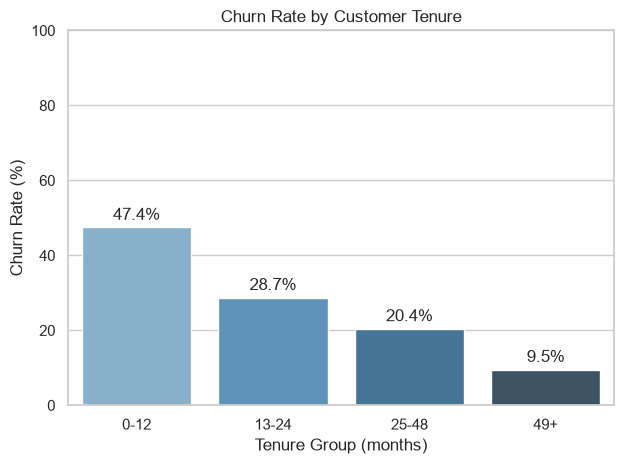

In [14]:
tenure_bins = [-1, 12, 24, 48, float("inf")]
tenure_labels = ["0-12", "13-24", "25-48", "49+"]

tenure_groups = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_groups_churn = (
    df.assign(TenureGroup=tenure_groups)
    .groupby("TenureGroup", observed=False)["Churn"]
    .agg(
        Customers="size",
        Churned=lambda values: values.eq("Yes").sum(),
        ChurnRate=lambda values: values.eq("Yes").mean() * 100
    )
    .reset_index()
)
display(tenure_groups_churn.round(2))

ax = sns.barplot(
    data=tenure_groups_churn,
    x="TenureGroup",
    y="ChurnRate",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False,
    dodge=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Customer Tenure",
    xlabel="Tenure Group (months)",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

The first-year segment has the highest churn rate at 47.44%. The rate declines consistently to 28.71% at 13–24 months, 20.39% at 25–48 months, and 9.51% after 49 months.

This monotonic pattern reinforces early tenure as the primary intervention window. Welcome journeys, proactive support, and first-year renewal offers are plausible retention initiatives to test.

### 10. Customer characteristics and churn

Examine how senior-citizen status, partner status, and dependent status are associated with churn.

,Status,Yes/No,Churn Rate
0,Senior Citizen,No,23.61
1,Senior Citizen,Yes,41.68
2,Partner,No,32.96
3,Partner,Yes,19.66
4,Dependents,No,31.28
5,Dependents,Yes,15.45


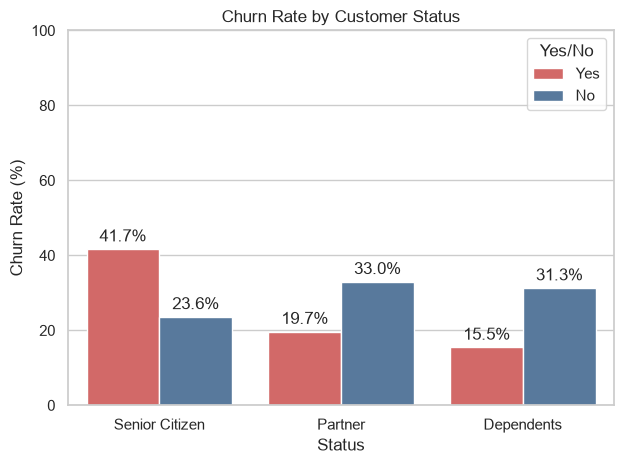

In [15]:
statuses = {"SeniorCitizen": "Senior Citizen", "Partner": "Partner", "Dependents": "Dependents"}

statuses_churn = (
    pd.concat(
        {
            label: df.groupby(col)["Churn"]
                        .value_counts(normalize=True)
                        .xs("Yes", level="Churn")
                        .mul(100)
            for col, label in statuses.items()
        },
        names=["Status", "Yes/No"]
    )
    .rename("Churn Rate")
    .reset_index()
)
display(statuses_churn.round(2))

ax = sns.barplot(
    data=statuses_churn,
    x="Status",
    y="Churn Rate",
    hue="Yes/No",
    hue_order=["Yes", "No"],
    palette=churn_palette
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Customer Status",
    xlabel="Status",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Senior citizens had a higher churn rate at 41.68%, compared with 23.61% for non-senior customers. Customers without a partner also had a higher churn rate at 32.96%, compared with 19.66% for customers with a partner. Similarly, customers without dependents churned at 31.28%, compared with 15.45% for customers with dependents. 

These results identify senior citizens and customers without partners or dependents as higher-risk groups in this dataset. Demographic attributes should be used carefully: they may reflect differences in tenure, service mix, or support needs, and any operational use should be reviewed for fairness and appropriate customer treatment.

---

## Feature-level summary

### Categorical features

The following table compares churn rates across every category. It is a useful screening view for identifying potentially informative features, but it does not measure statistical significance, control for other variables, or prove causality.

In [16]:
categorical_columns = [
    column
    for column in df.select_dtypes(include="str").columns
    if column not in ["Churn"]
]

summary_tables = []

for column in categorical_columns:
    feature_summary = (
        df.groupby(column)["Churn"]
        .agg(
            ChurnRate=lambda values: values.eq("Yes").mean() * 100
        )
        .reset_index()
        .rename(columns={column: "Category"})
    )

    feature_summary.insert(0, "Feature", column)
    summary_tables.append(feature_summary)

categorical_churn_summary = pd.concat(
    summary_tables,
    ignore_index=True
)

display(categorical_churn_summary.round(2))


,Feature,Category,ChurnRate
0,gender,Female,26.92
1,gender,Male,26.16
2,SeniorCitizen,No,23.61
3,SeniorCitizen,Yes,41.68
4,Partner,No,32.96
5,Partner,Yes,19.66
6,Dependents,No,31.28
7,Dependents,Yes,15.45
8,PhoneService,No,24.93
9,PhoneService,Yes,26.71


The largest category-level differences appear in `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `SeniorCitizen`, `Partner`, `Dependents`, and `PaperlessBilling`. These variables are strong candidates for predictive modeling.

By contrast, `gender`, `PhoneService`, `MultipleLines`, `StreamingTV`, and `StreamingMovies` show smaller unadjusted differences. They should not be dropped solely on this basis: a feature with a weak bivariate relationship can still add value through interactions or after adjustment for correlated variables. Feature removal should be supported by cross-validation, regularization, permutation importance, or another multivariate method.

### Numerical features

Compare the distribution of each numerical variable between churned and retained customers using summary statistics and box plots.

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

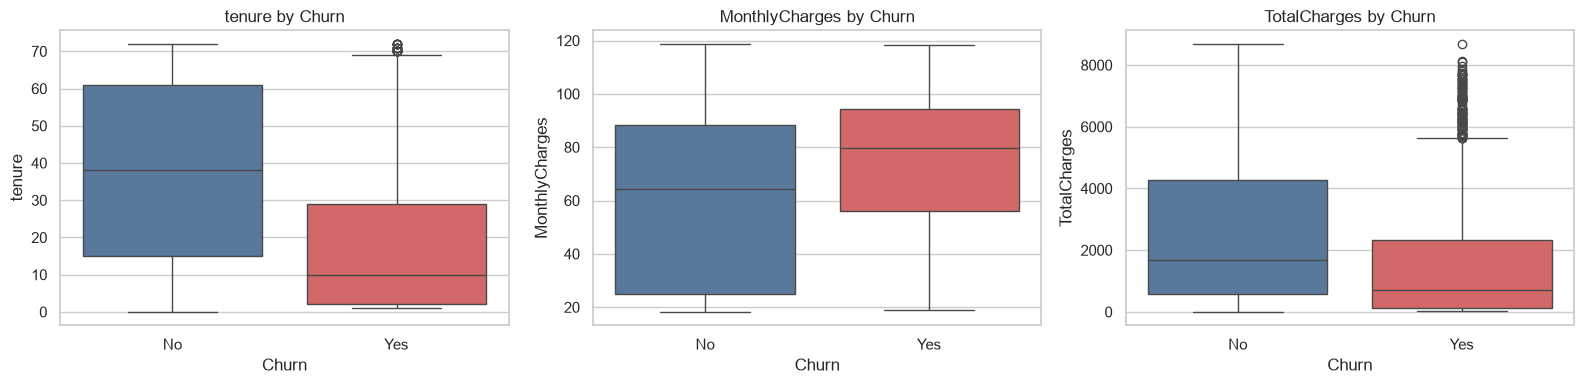

In [17]:
numerical_columns = [
    column
    for column in df.select_dtypes(exclude="str").columns
    if column not in ["Churn"]
]

numerical_churn_summary = (
    df.groupby("Churn")[numerical_columns]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .round(2)
)

display(numerical_churn_summary)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

for axis, column in zip(axes, numerical_columns):
    sns.boxplot(
        data=df,
        x="Churn",
        y=column,
        hue="Churn",
        palette=churn_palette,
        legend=False,
        ax=axis
    )

    axis.set_title(f"{column} by Churn")

plt.tight_layout()
plt.show()

All three numerical variables show distributional differences between churned and retained customers and are reasonable modeling candidates. Churned customers have shorter tenure and higher monthly charges on average. Their lower `TotalCharges` is consistent with their much shorter tenure, so it should not be interpreted as evidence that lower cumulative spending causes churn.

Because `TotalCharges`, `tenure`, and `MonthlyCharges` are mechanically related, their joint contribution should be evaluated within the model rather than from isolated averages.

---